In [1]:
# import Social_Network_Ads.csv

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Social_Network_Ads.csv")

In [5]:
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19.0,19000.0,0
1,15810944,Male,35.0,20000.0,0
2,15668575,Female,26.0,43000.0,0
3,15603246,Female,27.0,57000.0,0
4,15804002,Male,19.0,76000.0,0


In [6]:
df.isnull().sum()

User ID            0
Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

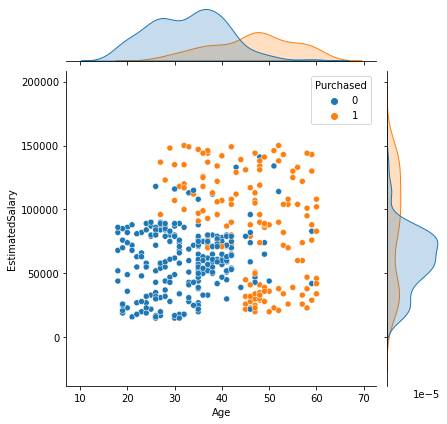

In [9]:
sns.jointplot(x="Age",y='EstimatedSalary',data= df,hue = 'Purchased');

In [11]:
"""
separate input and output 
check target distribution 
cross validation and features scaling

""";

In [23]:
#separate input and output 

x= df[['Age','EstimatedSalary']]
y = df['Purchased']
print("Input Features:")
print(X.head())
print("Output Labels:")
print(y.head())

Input Features:
    Age
0  19.0
1  35.0
2  26.0
3  27.0
4  19.0
Output Labels:
0    0
1    0
2    0
3    0
4    0
Name: Purchased, dtype: int64


Text(0.5, 1.0, 'Target Variable Distribution')

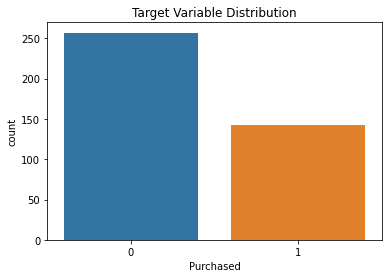

In [28]:
#check target distribution 
sns.countplot(x=y)
plt.title("Target Variable Distribution")



In [25]:
#cross validation and features scaling
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test =train_test_split(x,y,random_state=0)

In [26]:
#feature scaling

In [27]:
from sklearn.preprocessing import MinMaxScaler
sca = MinMaxScaler()

In [29]:
x_train_scaled = sca.fit_transform(x_train)
x_test_scaled = sca.fit(x_test)

In [59]:
# build the random forest model

In [60]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
# Create scaler
scaler = MinMaxScaler()
# Scale training data
x_train_scaled = scaler.fit_transform(x_train)
# Scale testing data
x_test_scaled = scaler.transform(x_test)
# Train model
rf = RandomForestClassifier()
rf.fit(x_train_scaled, y_train)
# Predict
y_pred = rf.predict(x_test_scaled)
print(y_pred)

[0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 1 0 1 0 0 1 0 1 0 0 0 0 0 0 0 0 1 0 0 0 0
 0 0 1 0 0 0 0 1 0 0 1 0 1 1 0 0 1 1 1 0 0 1 0 0 1 0 1 0 1 0 0 0 1 1 0 0 1
 0 0 0 0 1 1 1 1 0 0 1 0 0 1 1 0 0 1 0 0 0 0 0 1 1 1]


In [61]:
from sklearn.ensemble import RandomForestClassifier

In [62]:
rf = RandomForestClassifier(random_state=0,n_estimators = 50)

In [63]:
rf.fit(x_train_scaled,y_train)

RandomForestClassifier(n_estimators=50, random_state=0)

In [71]:
from sklearn.metrics import ConfusionMatrixDisplay,classification_report,accuracy_score

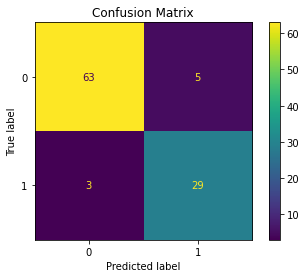

In [79]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)
# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

In [73]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.95      0.93      0.94        68
           1       0.85      0.91      0.88        32

    accuracy                           0.92       100
   macro avg       0.90      0.92      0.91       100
weighted avg       0.92      0.92      0.92       100



In [83]:
rf.estimators_;

In [80]:
# bagging of knn

In [82]:
# check the accuracy using individual knn  and compare with bagging of knn

In [91]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
knn = KNeighborsClassifier(n_neighbors=3)

knn.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=3)

In [94]:
y_pred= knn.predict(x_test_scaled)
accuracy_score(y_test,y_pred)

0.93

In [95]:
# bagging

In [96]:
from sklearn.ensemble import BaggingClassifier
bag = BaggingClassifier(KNeighborsClassifier(n_neighbors=5),random_state=0,n_estimators = 50)

In [97]:
bag.fit(x_train_scaled,y_train)

BaggingClassifier(base_estimator=KNeighborsClassifier(), n_estimators=50,
                  random_state=0)

In [98]:
y_pred = bag.predict(x_test_scaled)
accuracy_score(y_test,y_pred)

0.93

In [103]:
dl = pd.read_csv("train.csv")
dl.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [110]:
#x = train.drop('price_range', axis=1)
x = dl.drop('price_range', axis=1)
y = dl['price_range']

In [115]:
dl.isnull().sum()

battery_power    0
blue             0
clock_speed      0
dual_sim         0
fc               0
four_g           0
int_memory       0
m_dep            0
mobile_wt        0
n_cores          0
pc               0
px_height        0
px_width         0
ram              0
sc_h             0
sc_w             0
talk_time        0
three_g          0
touch_screen     0
wifi             0
price_range      0
dtype: int64

In [117]:
dl.shape

(2000, 21)

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
df = pd.read_csv("train.csv")
X = df.drop("price_range", axis=1)
y = df["price_range"]
X_train, X_test, y_train, y_test = train_test_split(
X, y, test_size=0.2, random_state=42
)
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Accuracy Score:", acc)

Accuracy Score: 0.7725


C:\ProgramData\Anaconda3\lib\site-packages\sklearn\linear_model\_logistic.py:763: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
